In [1]:
import cira 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from os.path import exists

import yfinance as yf

cira.auth.KEY_FILE = "../alpc_key.json"
assert cira.auth.check_keys(), "the set keys dose not work"

SYMBOL = "AAPL" 
SYM_HIST_FILE = f'./{SYMBOL.replace("/", "_")}.csv'


In [2]:
start_date = datetime(2016, 1, 1).date().strftime("%Y-%m-%d")
end_date = datetime.now().date().strftime("%Y-%m-%d")

<Axes: xlabel='Date'>

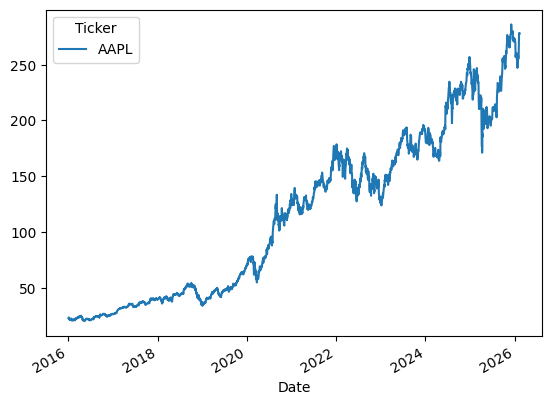

In [3]:
stock = yf.download(SYMBOL, start=start_date, end=end_date, progress=False)
stock["Open"].plot()

<Axes: xlabel='Date'>

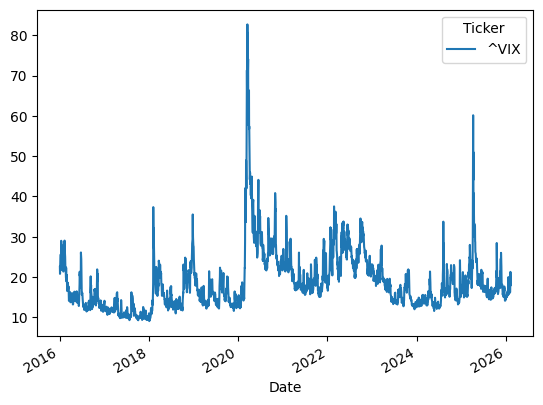

In [4]:
vix = yf.download('^VIX', start=start_date, end=end_date, progress=False)
vix["Open"].plot()

<Axes: xlabel='Date'>

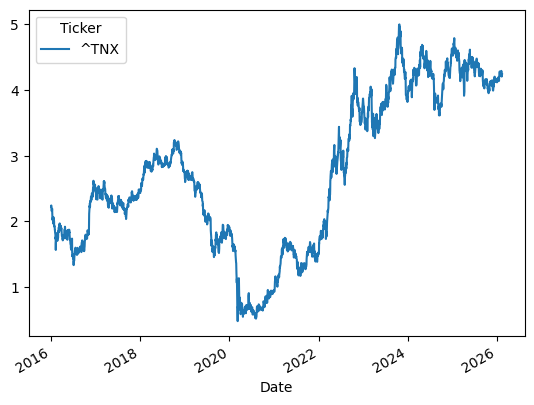

In [5]:
tnx = yf.download("^TNX", start=start_date, end=end_date, progress=False)
tnx["Open"].plot()

<Axes: xlabel='Date'>

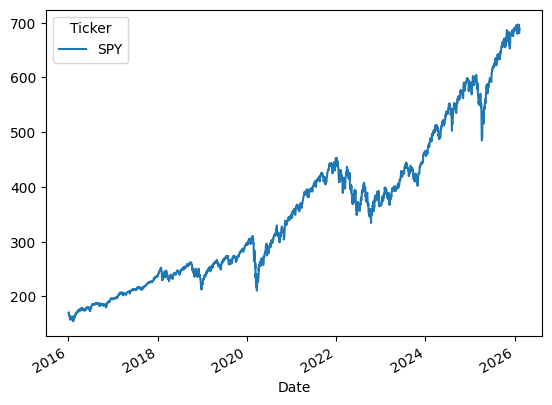

In [6]:
spy = yf.download("SPY", start=start_date, end=end_date, progress=False)
spy["Open"].plot()

<Axes: xlabel='Date'>

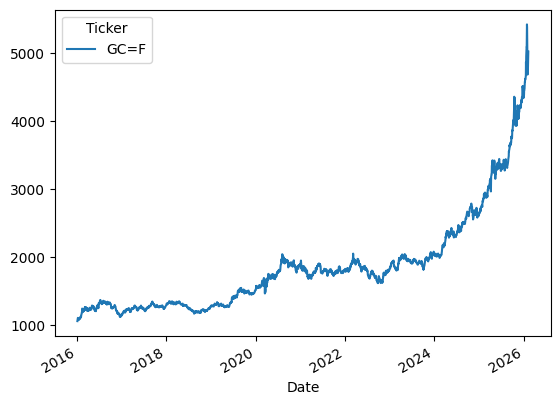

In [7]:
gold = yf.download("GC=F", start=start_date, end=end_date, progress=False)
gold["Open"].plot()

<Axes: xlabel='Date'>

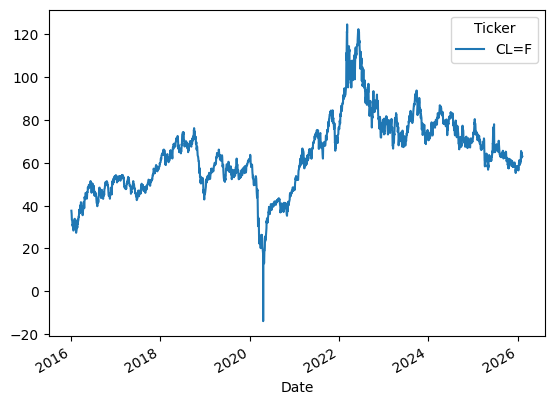

In [8]:
oil = yf.download("CL=F", start=start_date, end=end_date, progress=False)
oil["Open"].plot()

In [9]:
#data = pd.concat([a["Open"].to_frame() for a in [stock, vix, tnx, spy, gold, oil]])
data = stock["Open"]
for name, d in zip(["VIX", "TNX", "SPY", "GOLD", "OIL"], [vix, tnx, spy, gold, oil]):
    data[name] = d["Open"]
data.tail()

/var/folders/lv/g6xwdpyx3qd93zcp94tbn6b40000gn/T/ipykernel_72321/1371934968.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[name] = d["Open"]
/var/folders/lv/g6xwdpyx3qd93zcp94tbn6b40000gn/T/ipykernel_72321/1371934968.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[name] = d["Open"]
/var/folders/lv/g6xwdpyx3qd93zcp94tbn6b40000gn/T/ipykernel_72321/1371934968.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

Ticker,AAPL,VIX,TNX,SPY,GOLD,OIL
Date,,,,,,
2026-02-03,268.948351,16.160000,4.290,696.210022,4680.000000,62.279999
2026-02-04,272.035451,17.629999,4.268,690.349976,4923.299805,63.799999
2026-02-05,277.869995,19.240000,4.252,680.940002,5008.700195,64.489998
2026-02-06,276.860920,21.240000,4.204,681.460022,4762.000000,63.099998
2026-02-09,277.910004,17.950001,4.238,689.419983,5017.399902,62.990002


In [10]:
window_size = 5
data[SYMBOL] - data[SYMBOL].shift(window_size).fillna(data.iloc[0][SYMBOL].item())

Date
2016-01-04     0.000000
2016-01-05     0.707313
2016-01-06    -0.461778
2016-01-07    -0.885260
2016-01-08    -0.914545
                ...    
2026-02-03    10.020634
2026-02-04    14.626304
2026-02-05    20.111188
2026-02-06    21.929477
2026-02-09    18.123086
Name: AAPL, Length: 2540, dtype: float64

In [11]:
data.iloc[0][SYMBOL].item()

23.113738741825244

In [12]:
from fredapi import Fred
fred_key = open("../FRED.key", "r").read()[:-1]
fred_key

'1d042dd200059419acb9afc3ef493c06'

In [17]:
class FRED:
    def __init__(self, api_key:str):
        self.api_key = api_key
        self.client = Fred(api_key=fred_key)
    
    def get(self, series_id:str, start:datetime, end:datetime) -> pd.DataFrame:
        return pd.DataFrame({series_id:self.client.get_series(series_id, start, end)})

<Axes: >

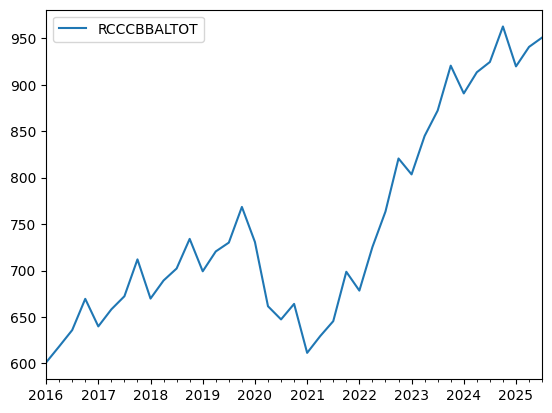

In [18]:
fred = FRED(fred_key)
data = fred.get('RCCCBBALTOT', datetime(2016, 1,1), datetime.now().date())
data.plot()

In [15]:
pd.DataFrame({"RCCCBBALTOT":data})

,RCCCBBALTOT
2012-07-01,571.03
2012-10-01,587.32
2013-01-01,556.67
2013-04-01,564.47
2013-07-01,564.23
2013-10-01,583.17
2014-01-01,554.59
2014-04-01,568.31
2014-07-01,575.60
2014-10-01,600.73
